In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

/home/ai/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid1_firefox_carbonyl21.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid2_firefox_carbonyl21.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid3_firefox_carbonyl21.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/odroid4_firefox_carbonyl21.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-4a_chrome_carbonyl21.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8a_chrome_carbonyl21.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8b_chrome_carbonyl21.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8c_chrome_carbonyl21.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_21/rpi-8d_chrome_carbonyl21.csv")

In [4]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,...,Feature 11,Feature 12,Feature 13,Feature 14,Feature 15,Feature 16,Feature 17,Feature 18,Feature 19,Feature 20
0,rpi-8c,62.6,61.2,60.6,59.8,60.0,59.9,60.2,60.1,60.3,...,59.6,59.7,59.7,60.3,59.7,60.2,59.8,59.8,59.9,59.7
1,rpi-8b,63.4,61.4,60.6,59.8,59.6,59.3,59.9,59.6,59.4,...,59.4,59.5,59.6,60.1,59.7,59.9,59.8,59.6,60.3,60.1
2,odroid3,88.1,85.8,84.6,83.2,83.0,82.4,82.6,82.8,83.2,...,82.9,83.1,82.9,83.0,83.0,83.0,82.9,83.1,82.7,82.8
3,odroid2,89.8,87.0,86.1,85.1,85.0,85.2,84.9,85.2,85.1,...,85.9,85.1,85.0,85.2,84.9,85.0,85.3,85.3,85.2,85.4
4,odroid4,89.3,87.0,86.2,85.1,84.7,84.7,84.5,84.5,85.0,...,84.8,84.7,84.7,84.7,84.9,84.8,84.9,84.6,84.6,85.0


In [6]:
len(df)

9000

In [8]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20240910_071845"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.1.99-1 (2024-07-15)
CPU Count:          12
Memory Avail:       10.88 GB / 15.86 GB (68.6%)
Disk Space Avail:   21.97 GB / 96.93 GB (22.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240910_071845"
Train Data Rows:    1000
Train Data Columns: 21
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['rpi-8c', 'rpi-8b', 'odroid3', 'odroid2', 'odroid4', 'rpi-4a', 'rpi-8a', 'rpi-8d', 'odroid1']
	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter duri

In [9]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.690120,0.686,0.674383
1,2000,0.717317,0.713,0.708747
2,3000,0.722915,0.719,0.715004
3,4000,0.733942,0.725,0.723116
4,5000,0.720607,0.707,0.708849
5,6000,0.740959,0.733,0.730770
6,7000,0.727980,0.724,0.721199
7,8000,0.746109,0.738,0.733830


<Axes: xlabel='data_amount', ylabel='value'>

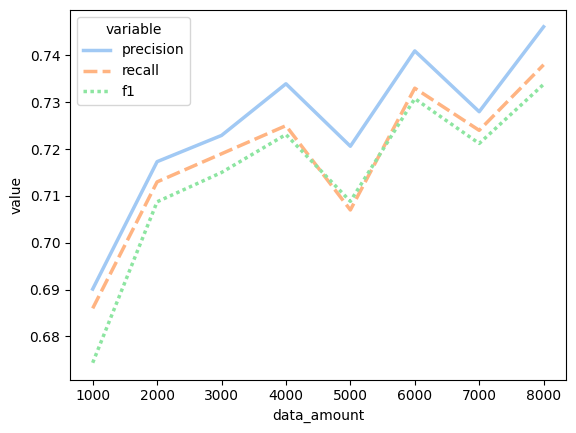

In [10]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [11]:
best_model

{'ExtraTreesGini': 3,
 'RandomForestGini': 6,
 'LightGBMXT': 3,
 'WeightedEnsemble_L2': 5,
 'RandomForestEntr': 5,
 'LightGBM': 1,
 'ExtraTreesEntr': 1}

([<matplotlib.patches.Wedge at 0x7fb457684c10>,
 [Text(1.0162674857624154, 0.4209517756015988, 'ExtraTreesGini'),
  Text(6.735557395310444e-17, 1.1, 'RandomForestGini'),
  Text(-1.0162674857624154, 0.4209517756015989, 'LightGBMXT'),
  Text(-0.872688684769691, -0.6696375582917576, 'WeightedEnsemble_L2'),
  Text(0.4209517280266836, -1.0162675054685892, 'RandomForestEntr'),
  Text(1.016267461129695, -0.42095183507024175, 'LightGBM'),
  Text(1.0905893402296634, -0.14357886675074355, 'ExtraTreesEntr')],
 [Text(0.5543277195067721, 0.22961005941905385, '12%'),
  Text(3.6739403974420595e-17, 0.6, '25%'),
  Text(-0.5543277195067721, 0.22961005941905394, '12%'),
  Text(-0.47601200987437686, -0.3652568499773223, '21%'),
  Text(0.22961003346910014, -0.5543277302555941, '21%'),
  Text(0.5543277060707427, -0.22961009185649545, '4%'),
  Text(0.5948669128525436, -0.07831574550040556, '4%')])

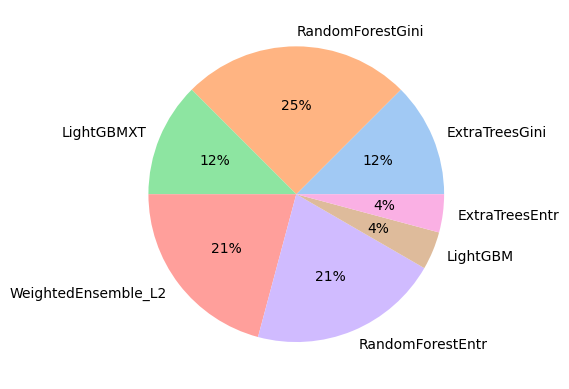

In [12]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [13]:
best_features

{'Feature 0': 8,
 'Feature 3': 2,
 'Feature 8': 5,
 'Feature 1': 5,
 'Feature 4': 1,
 'Feature 14': 1,
 'Feature 20': 2}

([<matplotlib.patches.Wedge at 0x7fb274330690>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 0'),
  Text(-0.7778175139235952, 0.7778174046868056, 'Feature 3'),
  Text(-1.0905893385493104, -0.1435788795142854, 'Feature 8'),
  Text(-0.14357877740594213, -1.0905893519921306, 'Feature 1'),
  Text(0.6696375889318861, -0.8726886612586934, 'Feature 4'),
  Text(0.8726886926066897, -0.6696375480783816, 'Feature 14'),
  Text(1.0625184200244853, -0.2847009081627096, 'Feature 20')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.42426409850377916, 0.42426403892007575, '8%'),
  Text(-0.5948669119359874, -0.07831575246233749, '21%'),
  Text(-0.07831569676687751, -0.5948669192684347, '21%'),
  Text(0.36525686669011964, -0.4760119970501963, '4%'),
  Text(0.47601201414910344, -0.3652568444063899, '4%'),
  Text(0.5795555018315374, -0.15529140445238704, '8%')])

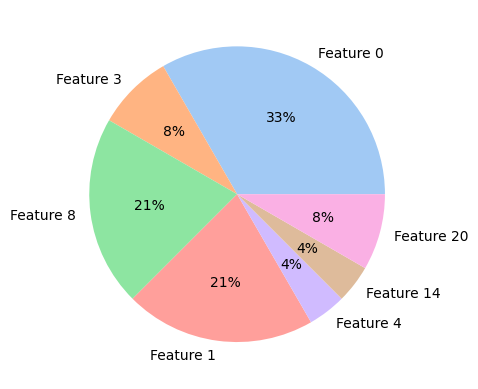

In [14]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [15]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 0,0.1226,0.010310,0.000006,5,0.143829,0.101371
Feature 20,0.0342,0.006723,0.000170,5,0.048043,0.020357
Feature 8,0.0298,0.003114,0.000014,5,0.036213,0.023387
Feature 3,0.0244,0.005367,0.000264,5,0.035450,0.013350
Feature 19,0.0196,0.004450,0.000298,5,0.028762,0.010438
Feature 14,0.0184,0.004159,0.000293,5,0.026964,0.009836
Feature 6,0.0164,0.004615,0.000679,5,0.025903,0.006897
Feature 18,0.0156,0.003782,0.000384,5,0.023386,0.007814
Feature 15,0.0150,0.005099,0.001382,5,0.025499,0.004501
Feature 1,0.0138,0.004087,0.000824,5,0.022214,0.005386
